# CRI Province Impact Demo from Normalized Silver/Gold Tables

This notebook demonstrates a province-level CRI-style impact index using the normalized tabulated data from various line agencies plus existing DDPM village-level disaster impact data.

## Scope
- Province-level demonstration only
- Uses cumulative / averaged 2560–2567-compatible inputs where possible
- Intended as an implementation demo, not the final production CRI pipeline


## Method summary
### Germanwatch-style Climate Risk Index
This notebook approximates the pilot-style impact score using six weighted components:
1. total deaths
2. deaths per 100k population
3. total affected people
4. affected people per 100k population
5. total government advance payment
6. loss relative to GPP

Each component is min-max normalized across provinces and weighted using the pilot weights.

### Additional impact metrics
1. Heat mortality from Department of Health


## Dataset origins
This notebook combines existing DDPM human-impact data with the new normalized tables derived from the Excel workbooks in `2026-06-12_cri_proj_data`.

### Human impact dataset
**Dataset used here**: [`fact_ddpm_tambon_impact_climate_2560_2567.csv`](ψ/incubate/DCCE/CRI/data_system/data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_2560_2567.csv:1)
- **Data owner**: กรมป้องกันและบรรเทาสาธารณภัย (DDPM / ปภ.)
- **How it is processed**: raw village-level DDPM files were consolidated and standardized first, then transformed into Gold tambon-level climate-impact facts. In this notebook I aggregate those Gold rows to province level to get deaths and affected people. The upstream DDPM lineage is summarized in `data-lineage.md`
- **Remarks**: this is the strongest human-impact layer in the current system because it already sits in a cleaned Gold analytical fact table.
- **Caution**: this is still reported disaster impact, not perfect ground truth. Low values can reflect lower impact, weaker reporting, or classification differences.

### Population denominator
**Dataset used here**: [`silver_population_annual.csv`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/population/silver_population_annual.csv:1)
- **Data owner**: Department of Provincial Administration (DOPA / กรมการปกครอง)
- **How it is processed**: the raw workbook was extracted by [`extract_population_tables.py`](ψ/incubate/DCCE/CRI/data_system/script/extract_population_tables.py:1) and normalized by [`normalize_population_to_silver.py`](ψ/incubate/DCCE/CRI/data_system/script/normalize_population_to_silver.py:1). In this notebook I keep only province rows and average them across 2560–2567 to create a stable denominator.
- **Remarks**: the definition extract explains that some `0` or `-` values indicate aggregate rows, not missing data; see [`cri-data-population.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-population.definition.md:18).
- **Caution**: some zeros are administrative codes rather than literal zero population. This is why the notebook keeps the province level, where the denominator is most reliable.

### Government Advance Payment dataset
**Dataset used here**: [`silver_govt_adv_payment_annual_long.csv`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/govt_adv_payment/silver_govt_adv_payment_annual_long.csv:1)
- **Data owner**: operationally rooted in DDPM / ปภ. reserve and disaster-related spending categories
- **How it is processed**: hazard-specific workbook sheets were extracted by [`extract_govt_adv_payment_hazard_sheets.py`](ψ/incubate/DCCE/CRI/data_system/script/extract_govt_adv_payment_hazard_sheets.py:1) and normalized by [`normalize_govt_adv_payment_to_silver.py`](ψ/incubate/DCCE/CRI/data_system/script/normalize_govt_adv_payment_to_silver.py:1). Province names were linked using [`province_code_lookup.csv`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/dopa/province_code_lookup.csv:1).
- **Remarks**: this gives a clean province-year-hazard economic series and is the main economic impact source used in the notebook.
- **Caution**: this is not a full actual-damage ledger. The workbook definition explicitly says it excludes some categories such as landslide, heat, local own-budget spending, agriculture compensation from another ministry, and donations; see [`cri-data-eco-loss.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-eco-loss.definition.md:16). So it is best read as a partial public-finance proxy for economic impact.

### GPP dataset
**Dataset used here**: [`silver_gpp_annual_long.csv`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/gpp/silver_gpp_annual_long.csv:1)
- **Data owner**: NESDC / สศช.
- **How it is processed**: the GPP workbook was extracted by [`extract_gpp_tables.py`](ψ/incubate/DCCE/CRI/data_system/script/extract_gpp_tables.py:1) and normalized by [`normalize_gpp_to_silver.py`](ψ/incubate/DCCE/CRI/data_system/script/normalize_gpp_to_silver.py:1). In this notebook I filter to `GPP_CURRENT_MARKET_PRICE` and average across 2560–2567.
- **Remarks**: the workbook definition says current-price GPP was chosen because disaster losses are monetary and should be compared against same-price economic output; see [`cri-data-gpp.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-gpp.definition.md:14).
- **Caution**: recent values may be provisional (`p`) or revised (`r`); see [`cri-data-gpp.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-gpp.definition.md:11). Averaging across years helps the demo, but smooths year-specific economic shocks.

### Heat mortality companion dataset
**Dataset used here**: [`silver_heatwave_impact_long.csv`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/heatwave/silver_heatwave_impact_long.csv:1)
- **Data owner**: field meanings are clear in the workbook definition, but the formal agency owner is not explicitly anchored in-place; see [`cri-data-heatwave.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-heatwave.definition.md:10).
- **How it is processed**: the workbook was extracted by [`extract_heatwave_table.py`](ψ/incubate/DCCE/CRI/data_system/script/extract_heatwave_table.py:1) and normalized by [`normalize_heatwave_to_silver.py`](ψ/incubate/DCCE/CRI/data_system/script/normalize_heatwave_to_silver.py:1). In this notebook I use cumulative heat mortality as a companion visualization metric.
- **Remarks**: the definition extract says heat records begin from 2561 onward; see [`cri-data-heatwave.definition.md`](ψ/incubate/DCCE/CRI/data_system/data/0_bronze/2026-06-12_cri_proj_data/definition_sheet_extracts/cri-data-heatwave.definition.md:13).
- **Caution**: heat data is not aligned to a full 2560–2567 annual panel, so it is shown for interpretation and planning context only. It is not used in the CRI score calculation.

### Map geometry
**Dataset used here**: [`province_boundaries_enriched.shp`](ψ/incubate/DCCE/CRI/data_system/data/1_silver/dopa/province_boundaries_enriched.shp)
- **Data owner**: DOPA administrative boundary base, enriched inside the CRI pipeline
- **How it is processed**: the enriched province geometry comes from the DOPA spatial workflow described in [`data-lineage.md`](ψ/incubate/DCCE/CRI/data_system/metadata/data-lineage.md:23).
- **Remarks**: it is appropriate for province choropleths because it already carries province identifiers.
- **Caution**: this is a presentation layer geometry, not itself an impact dataset.

### Scope note
This notebook is a **province-level demonstration**. It shows how the CRI-style impact score can be built from currently normalized inputs. Heat mortality metrics are visualized, but they are **not included** in the CRI demo score.


## How the CRI demo score is calculated
The scoring logic follows the pilot methodology in [`Climate Risk Index (CRI) Pilot Methodology.md`](ψ/incubate/DCCE/CRI/inbox_source/Climate%20Risk%20Index%20%28CRI%29%20Pilot%20Methodology.md:35). For each province, the notebook computes min-max normalized values and then applies the pilot weights:

- total deaths × `0.075`
- deaths per 100k × `0.225`
- affected people × `0.050`
- affected people per 100k × `0.150`
- government advance payment × `0.125`
- government advance payment per GPP × `0.375`

The final notebook score is:

`cri_demo_score = score_deaths + score_deaths_rate + score_affected + score_affected_rate + score_loss + score_loss_gpp`

### Calculation note
The code implements the correct weighted min-max structure for a pilot-style province impact index. Heat mortality and heat mortality per 100k are computed for visualization only and are **not** added into `cri_demo_score`.

### Important caution
This notebook is useful for demonstrating the score mechanics, but it is not the final fully governed production CRI dataset. It combines multiple sources that play different roles: DDPM for human impact, DOPA for population denominator, NESDC for GPP denominator, and a DDPM-style reserve/proxy financial-loss source for the economic side. That means the score is analytically meaningful, but it still depends on data gaps, reporting practices, and proxy choices in the underlying datasets.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

BASE_PATH = Path.cwd().resolve()
_p = BASE_PATH
while _p.name != 'data_system' and _p.parent != _p:
    _p = _p.parent
if _p.name != 'data_system':
    raise RuntimeError(f'Cannot locate data_system root from cwd: {Path.cwd().resolve()}')
BASE_PATH = _p

DDPM_FACT = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_2560_2567.csv'
ECO_LOSS = BASE_PATH / 'data/1_silver/govt_adv_payment/silver_govt_adv_payment_annual_long.csv'
GPP = BASE_PATH / 'data/1_silver/gpp/silver_gpp_annual_long.csv'
POP = BASE_PATH / 'data/1_silver/population/silver_population_annual.csv'
HEAT = BASE_PATH / 'data/1_silver/heatwave/silver_heatwave_impact_long.csv'
PROV_SHP_PATH = BASE_PATH / 'data/1_silver/dopa/province_boundaries_enriched.shp'
OUT_DIR = BASE_PATH / 'output/notebooks/cri_province_impact_demo'
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

print('BASE_PATH:', BASE_PATH)
print('DDPM_FACT:', DDPM_FACT)
print('ECO_LOSS:', ECO_LOSS)
print('GPP:', GPP)
print('POP:', POP)
print('HEAT:', HEAT)
print('PROV_SHP_PATH:', PROV_SHP_PATH)
print('OUT_DIR:', OUT_DIR)


BASE_PATH: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system
DDPM_FACT: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\2_gold\ddpm\fact_ddpm_tambon_impact_climate_2560_2567.csv
ECO_LOSS: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\govt_adv_payment\silver_govt_adv_payment_annual_long.csv
GPP: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\gpp\silver_gpp_annual_long.csv
POP: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\population\silver_population_annual.csv
HEAT: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\heatwave\silver_heatwave_impact_long.csv
PROV_SHP_PATH: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\dopa\province_boundaries_enriched.shp
OUT_DIR: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\

In [2]:
def minmax_score(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce').fillna(0.0).astype(float)
    mn = float(s.min()) if len(s) else 0.0
    mx = float(s.max()) if len(s) else 0.0
    denom = mx - mn
    if denom <= 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mn) / denom


## Load and prepare the four input families


In [3]:
ddpm = pd.read_csv(DDPM_FACT)
eco = pd.read_csv(ECO_LOSS)
gpp = pd.read_csv(GPP)
pop = pd.read_csv(POP)
heat = pd.read_csv(HEAT)

print('ddpm.shape =', ddpm.shape)
print('eco.shape =', eco.shape)
print('gpp.shape =', gpp.shape)
print('pop.shape =', pop.shape)
print('heat.shape =', heat.shape)


ddpm.shape = (6967, 13)
eco.shape = (1848, 23)
gpp.shape = (1848, 24)
pop.shape = (91104, 25)
heat.shape = (308, 28)


In [4]:
human = (
    ddpm.groupby(['province_code', 'province_name_th'], as_index=False)[['deaths_sum', 'affected_people_sum']]
    .sum()
)
human['province_code'] = human['province_code'].astype(str).str.zfill(2)

eco_prov = (
    eco.groupby(['province_code', 'province_name_th'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'loss_total_baht_2560_2567'})
)
eco_prov['province_code'] = eco_prov['province_code'].astype(str).str.zfill(2)

gpp_prov = (
    gpp[gpp['metric_code'] == 'GPP_CURRENT_MARKET_PRICE']
    .groupby(['province_code', 'province_name_th'], as_index=False)['value']
    .mean()
    .rename(columns={'value': 'gpp_avg_million_baht_2560_2567'})
)
gpp_prov['province_code'] = gpp_prov['province_code'].astype(str).str.zfill(2)

pop_prov = (
    pop[pop['geography_level'] == 'province']
    .groupby(['province_code', 'province_name_th'], as_index=False)['population_total']
    .mean()
    .rename(columns={'population_total': 'population_avg_2560_2567'})
)
pop_prov['province_code'] = pop_prov['province_code'].astype(str).str.zfill(2)

heat_mortality = (
    heat[(heat['metric_code'] == 'DEATHS') & (heat['time_scope'] == 'range_2561_2567')]
    .groupby(['province_code', 'province_name_th'], as_index=False)['value']
    .sum()
    .rename(columns={'value': 'heat_deaths_2561_2567'})
)
heat_mortality['province_code'] = heat_mortality['province_code'].astype(str).str.zfill(2)


## Build the province-level CRI-style demo table


In [5]:
df = human.merge(eco_prov, on=['province_code', 'province_name_th'], how='left')
df = df.merge(gpp_prov, on=['province_code', 'province_name_th'], how='left')
df = df.merge(pop_prov, on=['province_code', 'province_name_th'], how='left')
df = df.merge(heat_mortality, on=['province_code', 'province_name_th'], how='left')

df['loss_total_baht_2560_2567'] = pd.to_numeric(df['loss_total_baht_2560_2567'], errors='coerce').fillna(0.0)
df['gpp_avg_million_baht_2560_2567'] = pd.to_numeric(df['gpp_avg_million_baht_2560_2567'], errors='coerce')
df['population_avg_2560_2567'] = pd.to_numeric(df['population_avg_2560_2567'], errors='coerce')
df['heat_deaths_2561_2567'] = pd.to_numeric(df['heat_deaths_2561_2567'], errors='coerce').fillna(0.0)

df['deaths_per_100k'] = np.where(df['population_avg_2560_2567'] > 0, df['deaths_sum'] / df['population_avg_2560_2567'] * 100000.0, np.nan)
df['affected_per_100k'] = np.where(df['population_avg_2560_2567'] > 0, df['affected_people_sum'] / df['population_avg_2560_2567'] * 100000.0, np.nan)
df['loss_per_gpp'] = np.where(df['gpp_avg_million_baht_2560_2567'] > 0, df['loss_total_baht_2560_2567'] / (df['gpp_avg_million_baht_2560_2567'] * 1_000_000.0), np.nan)

df['score_deaths'] = minmax_score(df['deaths_sum']) * 0.075
df['score_deaths_rate'] = minmax_score(df['deaths_per_100k']) * 0.225
df['score_affected'] = minmax_score(df['affected_people_sum']) * 0.050
df['score_affected_rate'] = minmax_score(df['affected_per_100k']) * 0.150
df['score_loss'] = minmax_score(df['loss_total_baht_2560_2567']) * 0.125
df['score_loss_gpp'] = minmax_score(df['loss_per_gpp']) * 0.375

df['cri_demo_score'] = df[['score_deaths','score_deaths_rate','score_affected','score_affected_rate','score_loss','score_loss_gpp']].sum(axis=1)
df['cri_demo_rank'] = df['cri_demo_score'].rank(ascending=False, method='dense').astype(int)

df = df.sort_values(['cri_demo_rank', 'province_code']).reset_index(drop=True)
df.head(10)


,province_code,province_name_th,deaths_sum,affected_people_sum,loss_total_baht_2560_2567,gpp_avg_million_baht_2560_2567,population_avg_2560_2567,heat_deaths_2561_2567,deaths_per_100k,affected_per_100k,loss_per_gpp,score_deaths,score_deaths_rate,score_affected,score_affected_rate,score_loss,score_loss_gpp,cri_demo_score,cri_demo_rank
0,58,แม่ฮ่องสอน,5.0,1.0,4.603981e+08,1.568467e+04,NaN,1,NaN,NaN,0.029353,0.015625,0.0,1.667445e-07,0.00,0.036334,0.375000,0.426959,1
1,80,นครศรีธรรมราช,21.0,28978.0,1.583473e+09,1.806101e+05,NaN,1,NaN,NaN,0.008767,0.065625,0.0,4.831922e-03,0.00,0.125000,0.112002,0.307459,2
2,63,ตาก,4.0,31329.0,6.856393e+08,6.392998e+04,NaN,3,NaN,NaN,0.010725,0.012500,0.0,5.223938e-03,0.00,0.054116,0.137010,0.208851,3
3,10,กรุงเทพมหานคร,0.0,21.0,6.637225e+08,5.620290e+06,5570385.375,1,0.0,0.376994,0.000118,0.000000,0.0,3.501634e-06,0.15,0.052386,0.001503,0.203893,4
4,94,ปัตตานี,24.0,42575.0,3.196912e+08,5.085597e+04,NaN,0,NaN,NaN,0.006286,0.075000,0.0,7.099146e-03,0.00,0.025225,0.080304,0.187628,5
5,96,นราธิวาส,7.0,231749.0,2.913582e+08,4.490389e+04,NaN,0,NaN,NaN,0.006488,0.021875,0.0,3.864287e-02,0.00,0.022988,0.082888,0.166394,6
6,93,พัทลุง,8.0,2440.0,2.825371e+08,3.999229e+04,NaN,1,NaN,NaN,0.007065,0.025000,0.0,4.068565e-04,0.00,0.022292,0.090251,0.137949,7
7,84,สุราษฎร์ธานี,18.0,37999.0,5.085829e+08,2.119940e+05,NaN,2,NaN,NaN,0.002399,0.056250,0.0,6.336124e-03,0.00,0.040138,0.030643,0.133367,8
8,50,เชียงใหม่,19.0,299860.0,1.399623e+08,2.575826e+05,NaN,9,NaN,NaN,0.000543,0.059375,0.0,5.000000e-02,0.00,0.011035,0.006936,0.127347,9
9,56,พะเยา,6.0,6971.0,1.675657e+08,3.685227e+04,NaN,2,NaN,NaN,0.004547,0.018750,0.0,1.162376e-03,0.00,0.013215,0.058084,0.091211,10


## National province maps
Create national choropleths for the core raw metrics and the final CRI demo score.


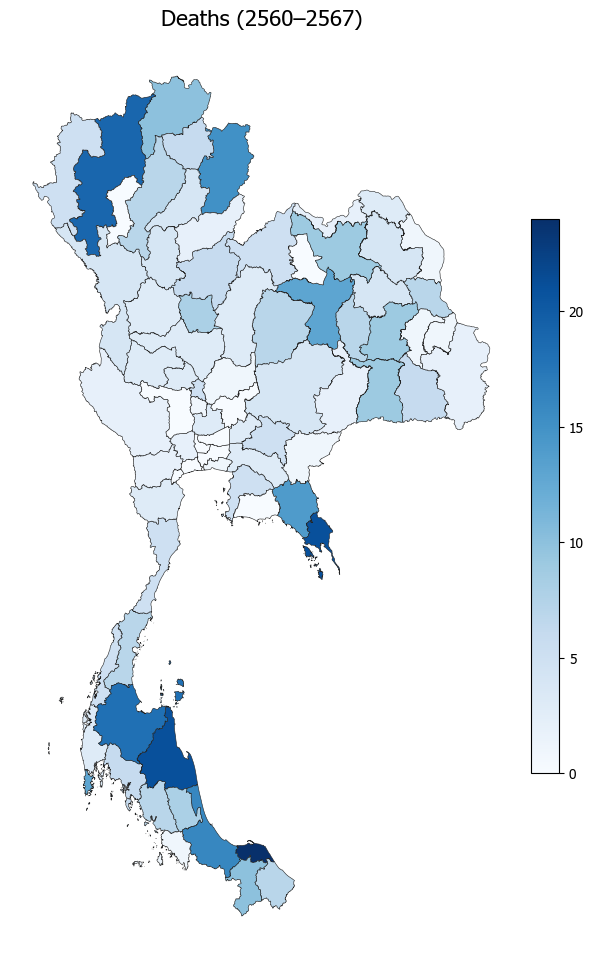

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_deaths_sum.png


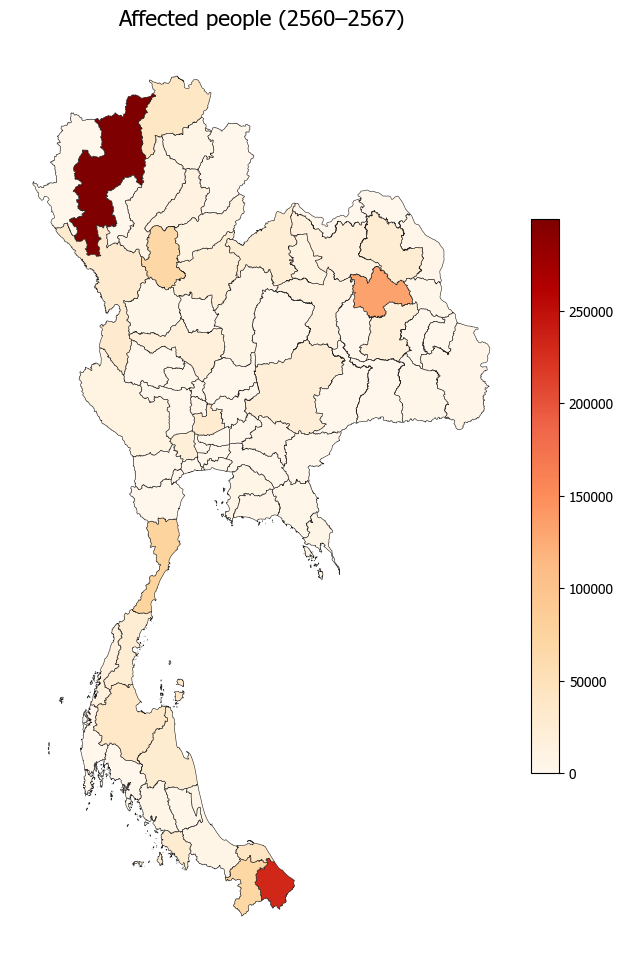

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_affected_people_sum.png


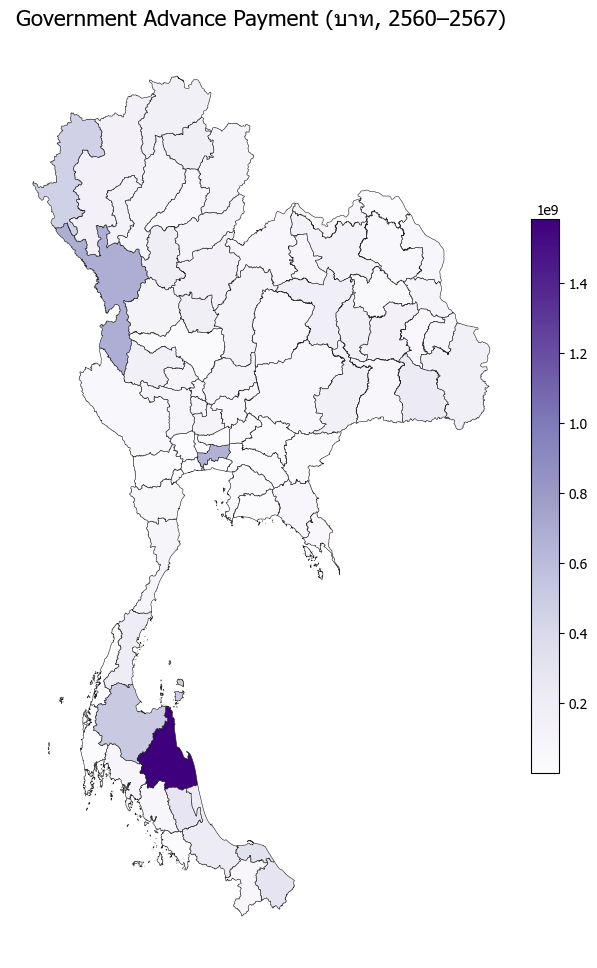

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_loss_total_baht_2560_2567.png


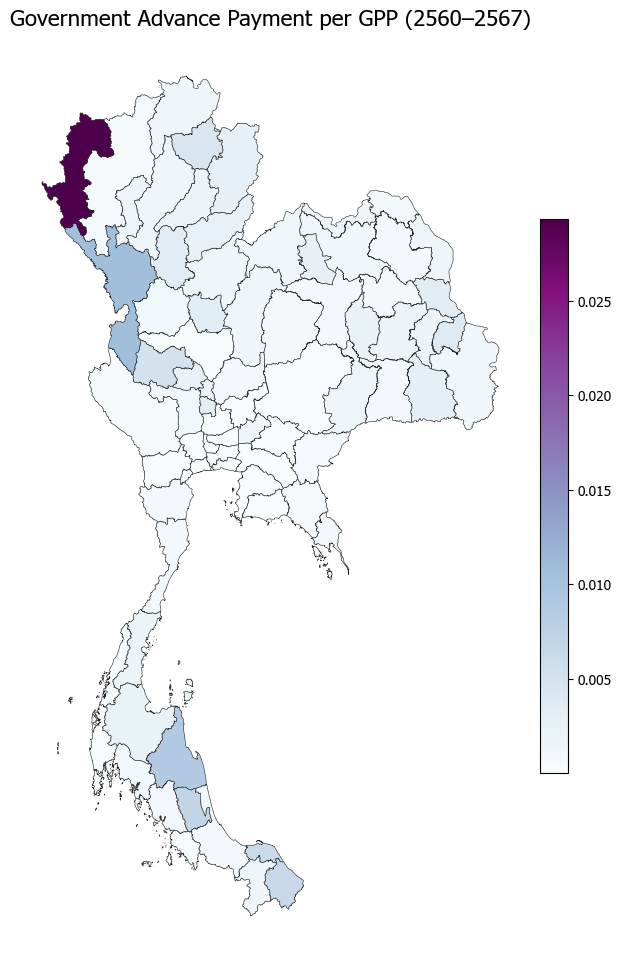

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_loss_per_gpp_2560_2567.png


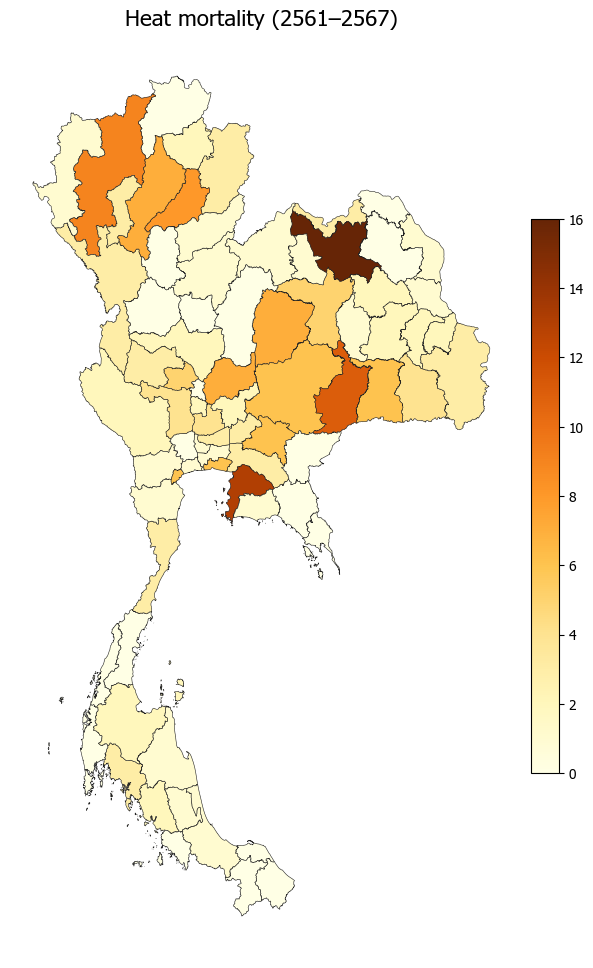

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_heat_deaths_2561_2567.png


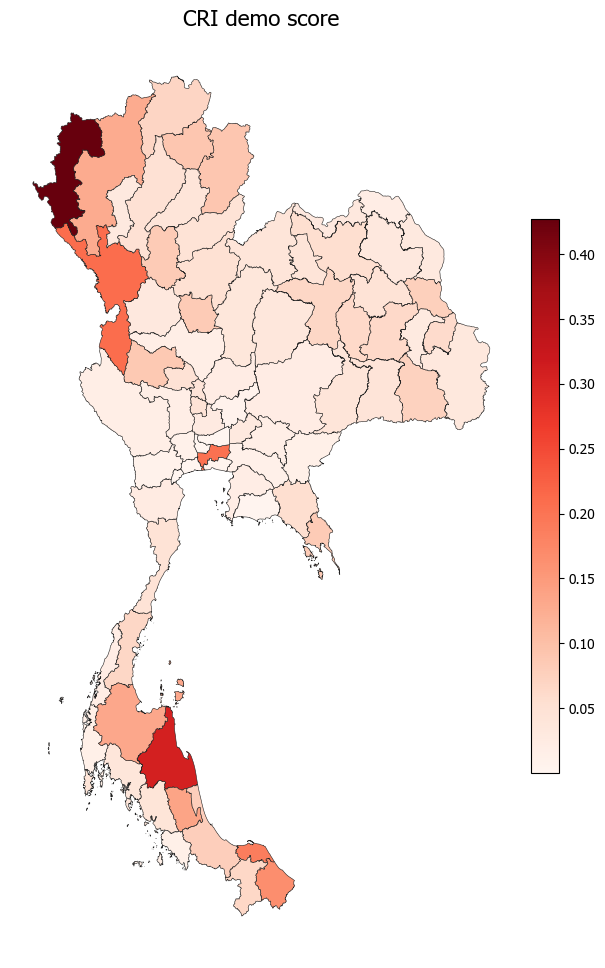

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\map_cri_demo_score.png


In [6]:
def _clean_code_2(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r'(\d+)')[0].fillna('')
    return s.str[-2:].str.zfill(2)

gdf_prov = gpd.read_file(PROV_SHP_PATH)
if gdf_prov.crs is None or gdf_prov.crs.to_epsg() != 4326:
    gdf_prov = gdf_prov.to_crs(epsg=4326)
gdf_prov = gdf_prov.copy()
gdf_prov['province_code'] = _clean_code_2(gdf_prov['prov_code'])
prov_map = gdf_prov.merge(df, on='province_code', how='left')

map_specs = [
    ('deaths_sum', 'Deaths (2560–2567)', 'Blues', 'map_deaths_sum.png'),
    ('affected_people_sum', 'Affected people (2560–2567)', 'OrRd', 'map_affected_people_sum.png'),
    ('loss_total_baht_2560_2567', 'Government Advance Payment (บาท, 2560–2567)', 'Purples', 'map_loss_total_baht_2560_2567.png'),
    ('loss_per_gpp', 'Government Advance Payment per GPP (2560–2567)', 'BuPu', 'map_loss_per_gpp_2560_2567.png'),
    ('heat_deaths_2561_2567', 'Heat mortality (2561–2567)', 'YlOrBr', 'map_heat_deaths_2561_2567.png'),
    ('cri_demo_score', 'CRI demo score', 'Reds', 'map_cri_demo_score.png'),
]

def plot_province_map(gdf, col, title, cmap, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_title(title, fontsize=16)
    ax.set_axis_off()
    gdf.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.04, 'pad': 0.02},
        linewidth=0.4,
        edgecolor='#222222',
        missing_kwds={'color': '#f0f0f0', 'edgecolor': 'none', 'label': 'No data'},
    )
    plt.show()
    out_png = OUT_DIR / filename
    fig.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print('Saved:', out_png)

for col, title, cmap, filename in map_specs:
    plot_province_map(prov_map, col, title, cmap, filename)


## Top 10 provinces by each core metric
This section surfaces the leading provinces for each raw and scored component used in the demo.


In [7]:
top_metric_cols = [
    'deaths_sum',
    'deaths_per_100k',
    'affected_people_sum',
    'affected_per_100k',
    'loss_total_baht_2560_2567',
    'loss_per_gpp',
    'heat_deaths_2561_2567',
    'cri_demo_score',
]

for col in top_metric_cols:
    print(f'\n### Top 10 by {col}')
    display(df[['province_code', 'province_name_th', col]].sort_values(col, ascending=False).head(10))



### Top 10 by deaths_sum


,province_code,province_name_th,deaths_sum
4,94,ปัตตานี,24.0
1,80,นครศรีธรรมราช,21.0
12,23,ตราด,21.0
8,50,เชียงใหม่,19.0
7,84,สุราษฎร์ธานี,18.0
15,90,สงขลา,16.0
10,55,น่าน,15.0
26,22,จันทบุรี,14.0
19,40,ขอนแก่น,13.0
37,83,ภูเก็ต,13.0



### Top 10 by deaths_per_100k


,province_code,province_name_th,deaths_per_100k
3,10,กรุงเทพมหานคร,0.0
0,58,แม่ฮ่องสอน,NaN
1,80,นครศรีธรรมราช,NaN
2,63,ตาก,NaN
4,94,ปัตตานี,NaN
5,96,นราธิวาส,NaN
6,93,พัทลุง,NaN
7,84,สุราษฎร์ธานี,NaN
8,50,เชียงใหม่,NaN
9,56,พะเยา,NaN



### Top 10 by affected_people_sum


...

,province_code,province_name_th,loss_per_gpp
0,58,แม่ฮ่องสอน,0.029353
2,63,ตาก,0.010725
1,80,นครศรีธรรมราช,0.008767
6,93,พัทลุง,0.007065
5,96,นราธิวาส,0.006488
4,94,ปัตตานี,0.006286
11,61,อุทัยธานี,0.005149
9,56,พะเยา,0.004547
24,37,อำนาจเจริญ,0.004032
16,49,มุกดาหาร,0.003647



### Top 10 by heat_deaths_2561_2567


,province_code,province_name_th,heat_deaths_2561_2567
25,41,อุดรธานี,16
58,20,ชลบุรี,13
39,31,บุรีรัมย์,11
8,50,เชียงใหม่,9
40,54,แพร่,8
28,52,ลำปาง,7
56,16,ลพบุรี,7
44,36,ชัยภูมิ,7
34,32,สุรินทร์,6
71,11,สมุทรปราการ,6



### Top 10 by cri_demo_score


,province_code,province_name_th,cri_demo_score
0,58,แม่ฮ่องสอน,0.426959
1,80,นครศรีธรรมราช,0.307459
2,63,ตาก,0.208851
3,10,กรุงเทพมหานคร,0.203893
4,94,ปัตตานี,0.187628
5,96,นราธิวาส,0.166394
6,93,พัทลุง,0.137949
7,84,สุราษฎร์ธานี,0.133367
8,50,เชียงใหม่,0.127347
9,56,พะเยา,0.091211


## Statistical summary
Summary statistics for the raw indicators and the final demonstration score.


In [8]:
summary_cols = [
    'deaths_sum',
    'deaths_per_100k',
    'affected_people_sum',
    'affected_per_100k',
    'loss_total_baht_2560_2567',
    'loss_per_gpp',
    'heat_deaths_2561_2567',
    'cri_demo_score',
]

summary_df = df[summary_cols].describe().T
summary_df


,count,mean,std,min,25%,50%,75%,max
deaths_sum,77.0,5.506494e+00,5.485923e+00,0.000000e+00,2.000000e+00,4.000000e+00,7.000000e+00,2.400000e+01
deaths_per_100k,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
affected_people_sum,77.0,1.930386e+04,4.617767e+04,0.000000e+00,3.470000e+02,3.720000e+03,1.863700e+04,2.998600e+05
affected_per_100k,1.0,3.769937e-01,NaN,3.769937e-01,3.769937e-01,3.769937e-01,3.769937e-01,3.769937e-01
loss_total_baht_2560_2567,77.0,1.379299e+08,2.121510e+08,1.844640e+05,4.722878e+07,8.508075e+07,1.527603e+08,1.583473e+09
loss_per_gpp,77.0,2.079758e-03,3.748612e-03,4.443685e-07,3.910420e-04,1.104960e-03,2.375724e-03,2.935338e-02
heat_deaths_2561_2567,77.0,2.623377e+00,3.133180e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,1.600000e+01
cri_demo_score,77.0,5.981399e-02,6.811562e-02,1.600747e-05,2.154527e-02,4.230414e-02,6.784602e-02,4.269588e-01


## Histograms
Distribution views for the core metrics and the final demonstration score.


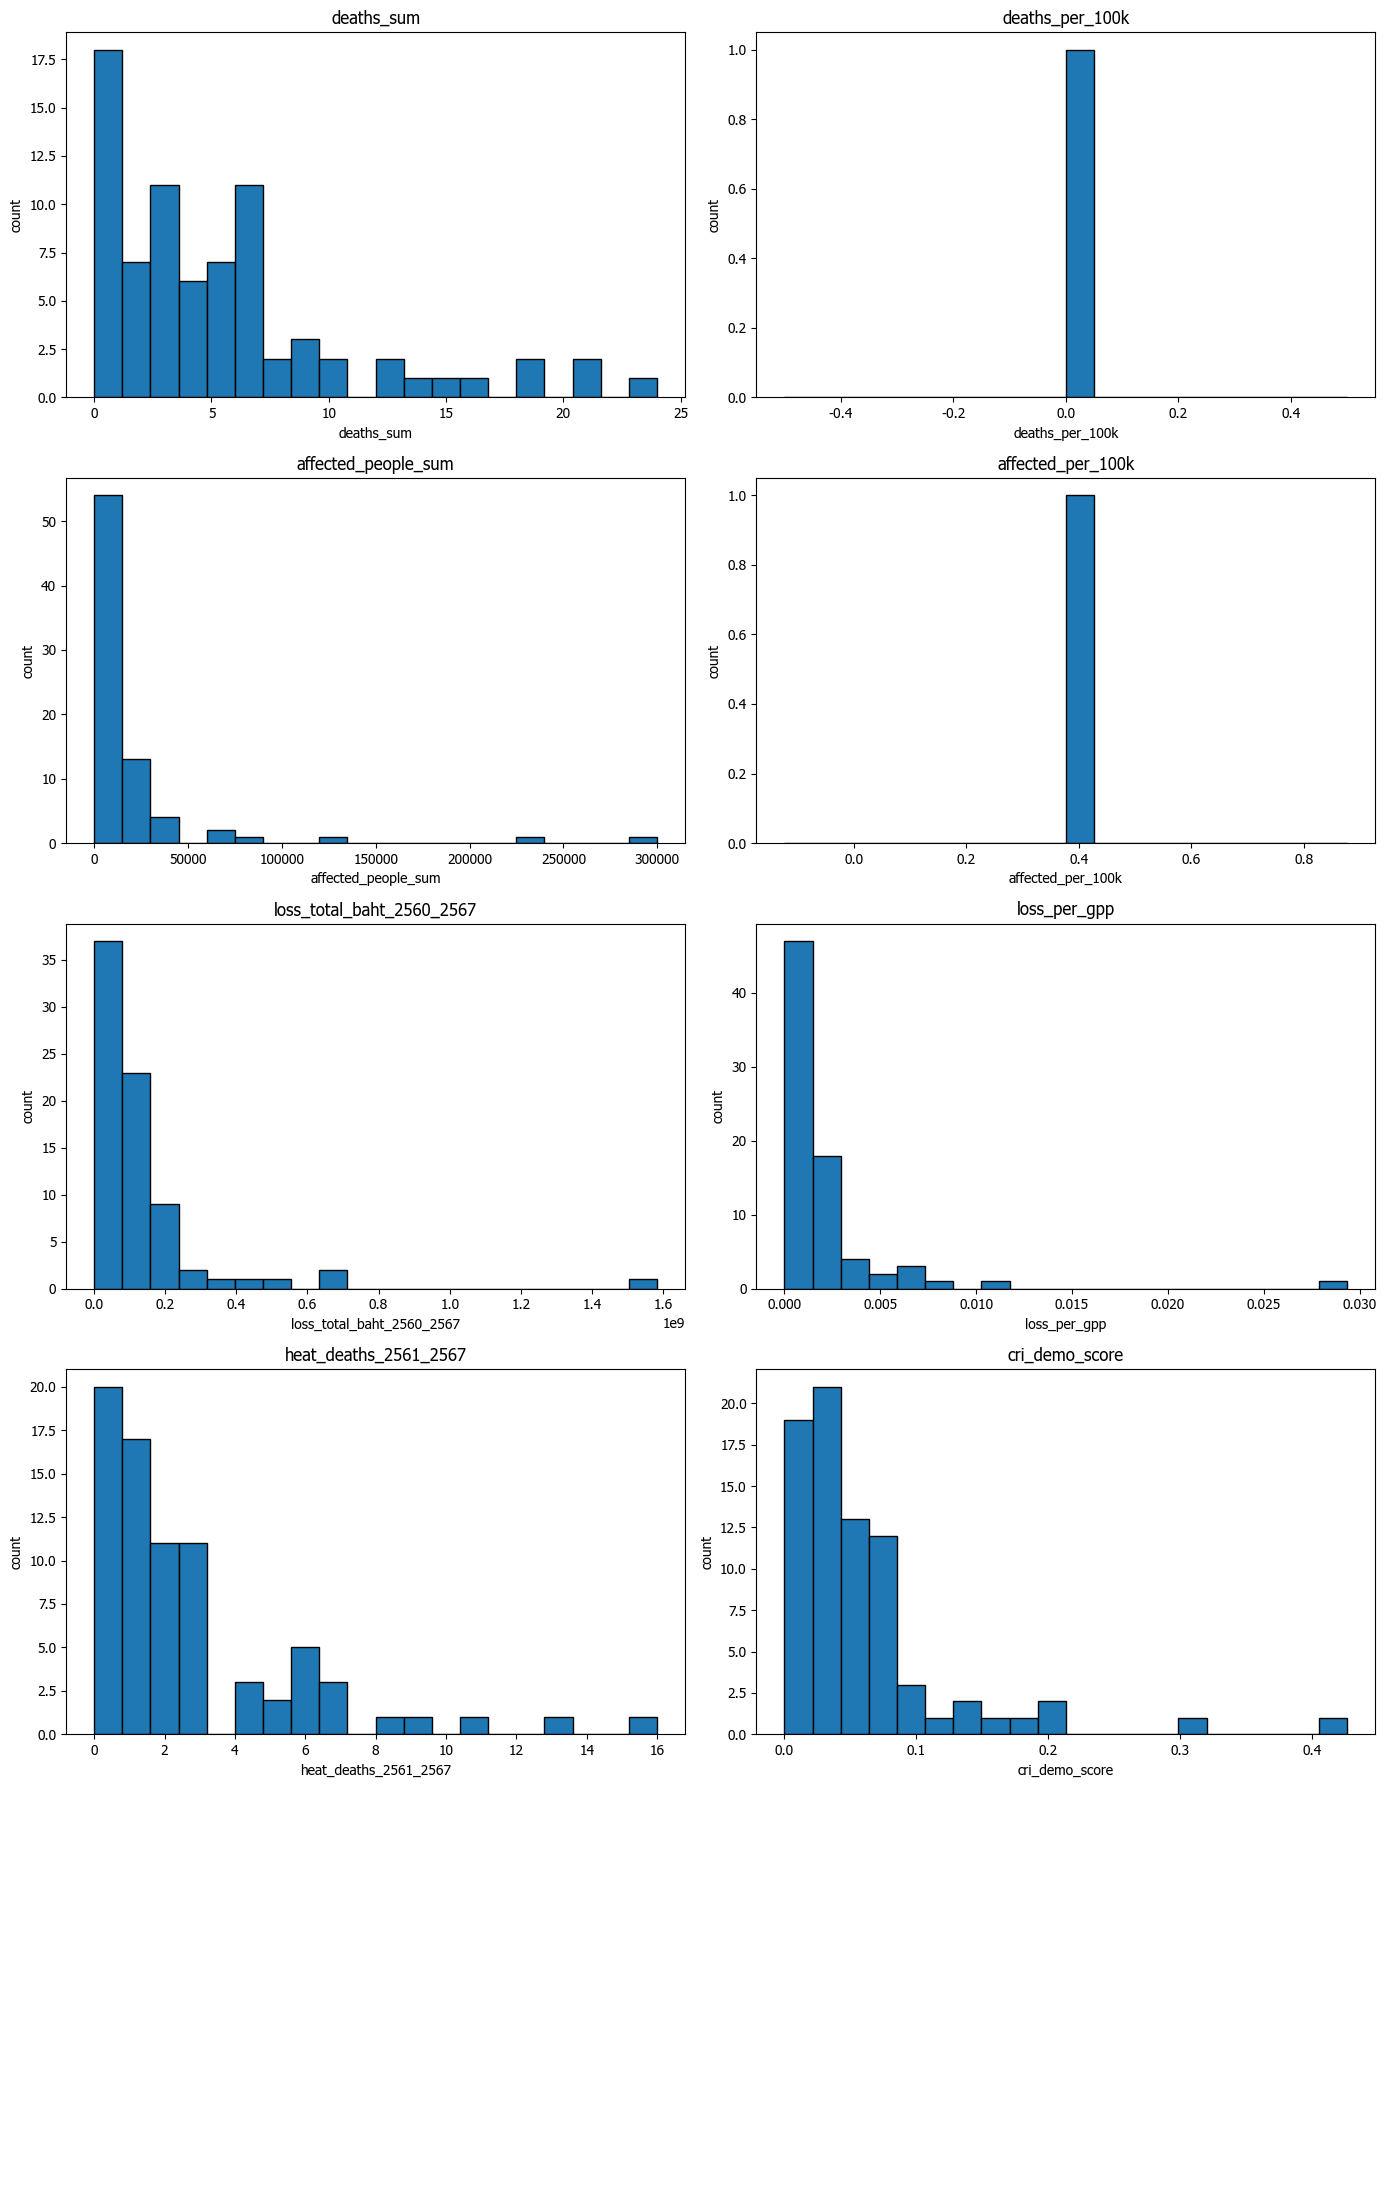

In [9]:
import matplotlib.pyplot as plt

hist_cols = [
    'deaths_sum',
    'deaths_per_100k',
    'affected_people_sum',
    'affected_per_100k',
    'loss_total_baht_2560_2567',
    'loss_per_gpp',
    'heat_deaths_2561_2567',
    'cri_demo_score',
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 22))
axes = axes.flatten()
for ax, col in zip(axes, hist_cols):
    df[col].dropna().plot(kind='hist', bins=20, ax=ax, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')

for ax in axes[len(hist_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Export the demonstration table


In [10]:
out_csv = OUT_DIR / 'province_year_cri_impact_demo.csv'
df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print('WROTE:', out_csv)
print('rows:', len(df))


WROTE: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\notebooks\cri_province_impact_demo\province_year_cri_impact_demo.csv
rows: 77


## Caveats
- This notebook demonstrates a province-level CRI-style implementation, not the final production CRI pipeline.
- Heatwave remains province-only and is not yet integrated into a full 2560–2567 annual panel.
- Economic components are province-level only; granular human-impact products should be treated separately from the full CRI-style index.
- Heat mortality and heat mortality per 100k are visualized as companion metrics but are not included in the CRI demo score calculation.
- Missing-vs-zero ambiguity still requires governance interpretation when publishing final results.
